In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

#for linear regression
from sklearn.linear_model import LinearRegression

import seaborn as sns
import statsmodels.api as sm

#for metrics ;  R2, RMSE, and MAE
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [24]:
#read data files

url_1 = "dodgers-2022.csv"
df = pd.read_csv(url_1, encoding="latin1")  # or utf-8 if latin1 fails

print(df.shape)        # (rows, columns)
print(df.info()) #no missing values indicated

(81, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   month        81 non-null     object
 1   day          81 non-null     int64 
 2   attend       81 non-null     int64 
 3   day_of_week  81 non-null     object
 4   opponent     81 non-null     object
 5   temp         81 non-null     int64 
 6   skies        81 non-null     object
 7   day_night    81 non-null     object
 8   cap          81 non-null     object
 9   shirt        81 non-null     object
 10  fireworks    81 non-null     object
 11  bobblehead   81 non-null     object
dtypes: int64(3), object(9)
memory usage: 7.7+ KB
None


In [25]:
df.head()

,month,day,attend,day_of_week,opponent,temp,skies,day_night,cap,shirt,fireworks,bobblehead
0,APR,10,56000,Tuesday,Pirates,67,Clear,Day,NO,NO,NO,NO
1,APR,11,29729,Wednesday,Pirates,58,Cloudy,Night,NO,NO,NO,NO
2,APR,12,28328,Thursday,Pirates,57,Cloudy,Night,NO,NO,NO,NO
3,APR,13,31601,Friday,Padres,54,Cloudy,Night,NO,NO,YES,NO
4,APR,14,46549,Saturday,Padres,57,Cloudy,Night,NO,NO,NO,NO


In [26]:
#Remove the opponent column.
df = df.drop('opponent', axis=1)

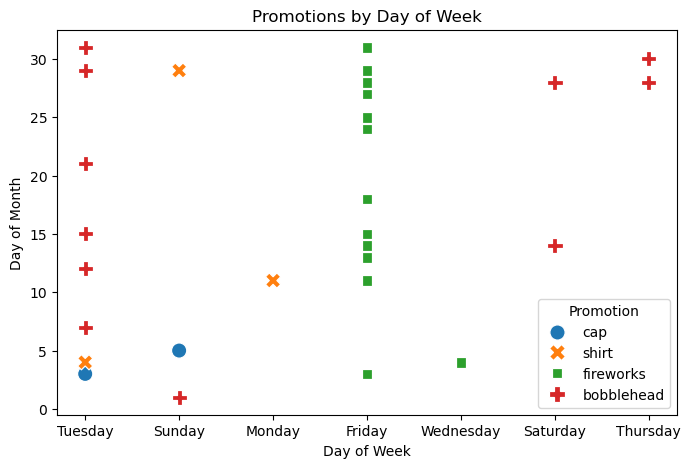

In [30]:
# format promotions column
promo_cols = ["cap","shirt","fireworks","bobblehead"]
df_melted = df.melt(
    id_vars=["month","day","day_of_week"], 
    value_vars=promo_cols,
    var_name="promotion",
    value_name="yes_no")

# Keep only YES promotions
df_promos = df_melted[df_melted["yes_no"] == "YES"]

# Plot promotions vs day of week
#doing this to see if there are any indicators that could cause the day attendance to be higher or lower
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_promos, 
    x="day_of_week", y="day", 
    hue="promotion", 
    style="promotion", 
    s=120)

plt.title("Promotions by Day of Week")
plt.ylabel("Day of Month")
plt.xlabel("Day of Week")
plt.legend(title="Promotion")
plt.show()

In [31]:
# Convert categorical columns to numeric using one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

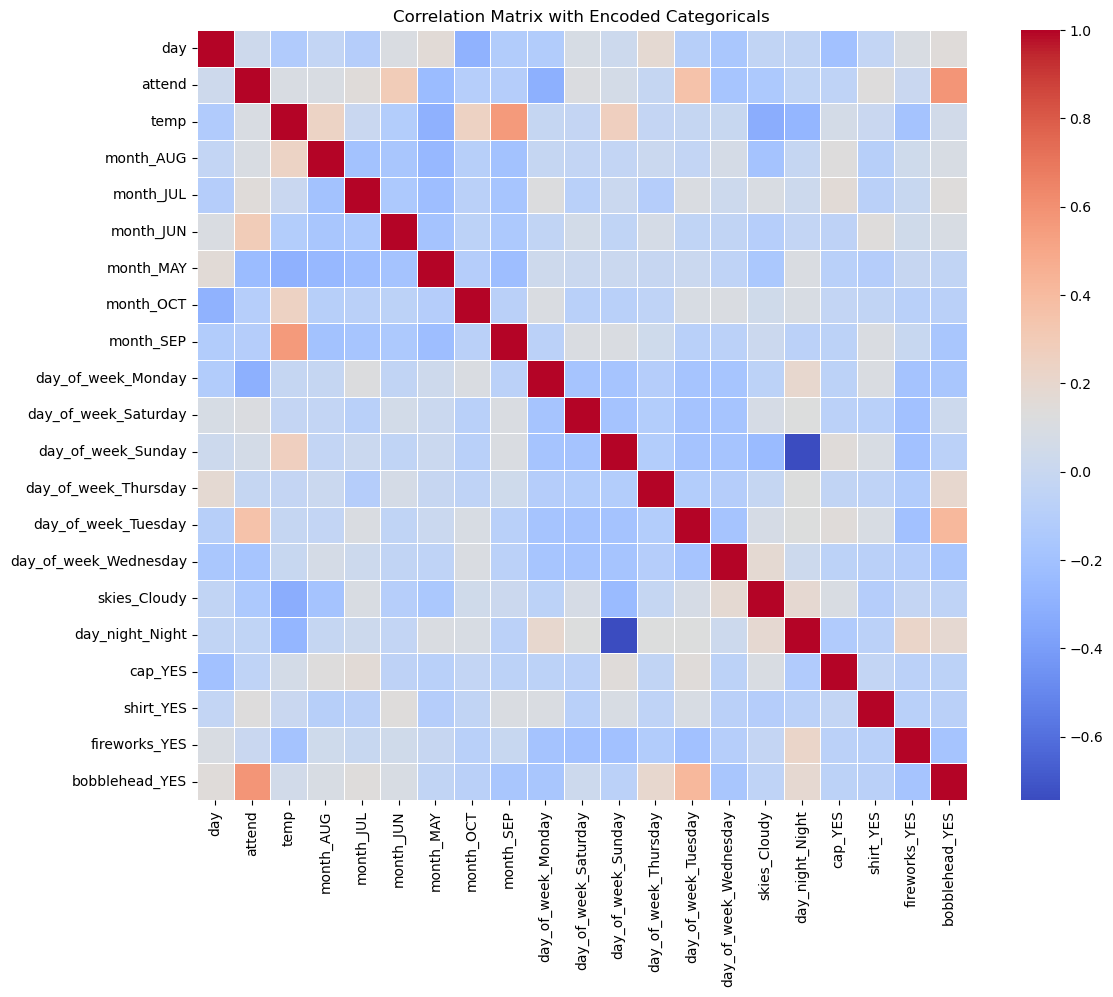

In [32]:
# Compute correlation matrix
corr_matrix = df_encoded.corr()

# Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix with Encoded Categoricals")
plt.show()

In [33]:
#get averages for multiple features and attendance

# average attendance overall
print("Average attendance:", df["attend"].mean())

# promotions
print(df.groupby("bobblehead")["attend"].mean())
print(df.groupby("fireworks")["attend"].mean())

# day of week
print(df.groupby("day_of_week")["attend"].mean())

# day vs night
print(df.groupby("day_night")["attend"].mean())

Average attendance: 41040.07407407407
bobblehead
NO     39137.928571
YES    53144.636364
Name: attend, dtype: float64
fireworks
NO     41032.179104
YES    41077.857143
Name: attend, dtype: float64
day_of_week
Friday       40116.923077
Monday       34965.666667
Saturday     43072.923077
Sunday       42268.846154
Thursday     40407.400000
Tuesday      47741.230769
Wednesday    37585.166667
Name: attend, dtype: float64
day_night
Day      41793.266667
Night    40868.893939
Name: attend, dtype: float64


In [34]:
#This indicates that the average attendance is higher for a day game vs night game,  Tuesdays have the highest attendance and the bobble head promotion may increase attendance. 

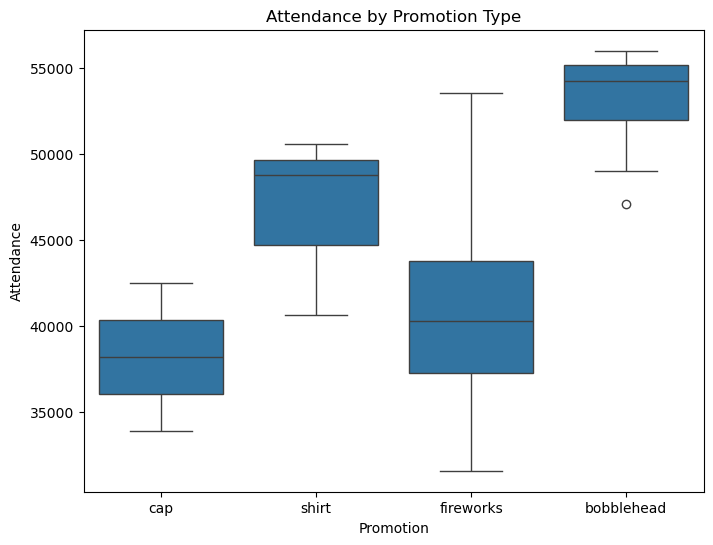

In [35]:
#I'd like to see which promotions potentially attract more viewers. 

df_melted = df.melt(
    id_vars=["attend"], 
    value_vars=promo_cols,
    var_name="promotion",
    value_name="yes_no"
)

# Keep only rows where a promotion happened
df_promos = df_melted[df_melted["yes_no"] == "YES"]

# Create boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x="promotion", y="attend", data=df_promos)
plt.title("Attendance by Promotion Type")
plt.ylabel("Attendance")
plt.xlabel("Promotion")
plt.show()

In [37]:
# Separate features and target variable
X = df.drop(columns=['attend'])
y = df['attend']

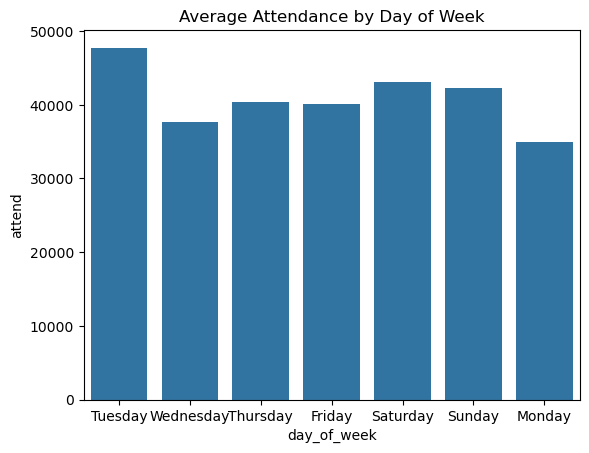

In [38]:
# attendance by day of week
sns.barplot(x="day_of_week", y="attend", data=df, estimator="mean", errorbar=None)
plt.title("Average Attendance by Day of Week")
plt.show()

In [ ]:
#Tuesday has the highest attendance average. Tuesday is also the day that often has a bobblehead giveaway. 

In [39]:
#Randomly split the data into 80% training data and 20% test data, where your target is attend.

# Weight as X
X = df_encoded.drop(columns=['attend'])

# Target = 'attend'
y = df_encoded['attend']


In [12]:
# Ensure everything is numeric
X = X.astype(float)
y = y.astype(float)

In [13]:
# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #42 is to recreate the data
  

# Check the shape of the splits
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape) 

Training set: (64, 20) (64,)
Test set: (17, 20) (17,)


In [14]:
#Train an ordinary linear regression on the training data. Y = mX + c

# Create linear regression
regression = LinearRegression()

# Fit the model on training data
model= regression.fit(X_train, y_train)

In [19]:
#evaluate the model

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.14930115037562586
MSE: 83642561.03849183


In [20]:

# Add intercept
X_sm = sm.add_constant(X)

# Fit OLS model
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 attend   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     5.039
Date:                Sun, 28 Sep 2025   Prob (F-statistic):           5.47e-07
Time:                        20:15:24   Log-Likelihood:                -805.43
No. Observations:                  81   AIC:                             1653.
Df Residuals:                      60   BIC:                             1703.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  1.706e+

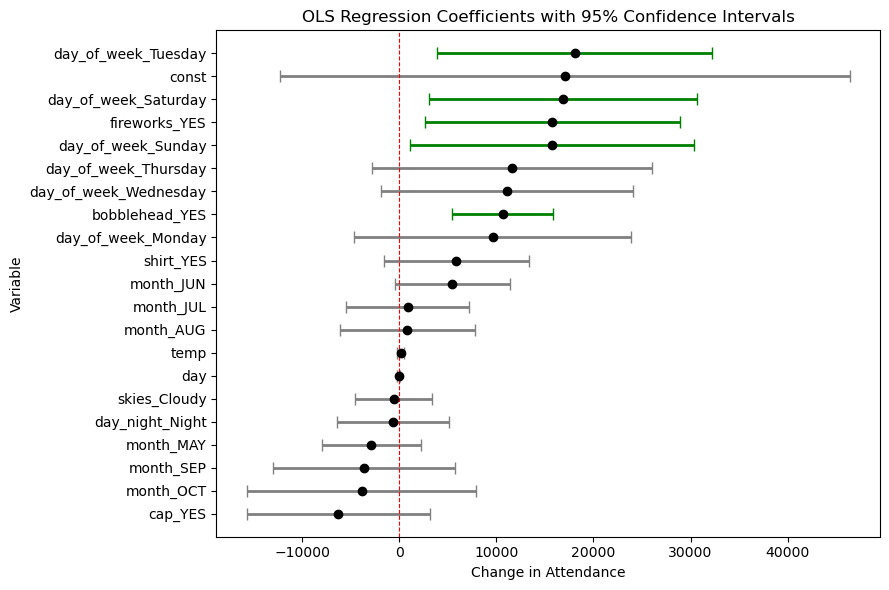

In [21]:
# Extract regression results
results = ols_model  

coef = results.params         # coefficients
conf = results.conf_int()     # confidence intervals
pvals = results.pvalues       # p-values

# Add to DataFrame
df = pd.DataFrame({
    "Coef": coef,
    "Lower_CI": conf[0],
    "Upper_CI": conf[1],
    "P_value": pvals
})

df["Variable"] = df.index
df["Significant"] = df["P_value"] < 0.05

# Sort for better plotting
df_sorted = df.sort_values("Coef")

# Plot
plt.figure(figsize=(9, 6))
for i, row in df_sorted.iterrows():
    color = "green" if row["Significant"] else "gray"
    plt.errorbar(
        row["Coef"], row["Variable"],
        xerr=[[row["Coef"] - row["Lower_CI"]], [row["Upper_CI"] - row["Coef"]]],
        fmt="o", color="black", ecolor=color,
        elinewidth=2, capsize=4)

plt.axvline(0, color="red", linestyle="--", linewidth=0.8)
plt.title("OLS Regression Coefficients with 95% Confidence Intervals")
plt.xlabel("Change in Attendance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

For this analysis I completed an OLS model which can explain 63% of the attendance variation. The average attendance of a game is 41040. The average attendance increases with the bobblehead and firework promotion which shirt and cap promotions don't show statistical significance.  Tuesday and weekend games show an increase in attendance, but it's also been pointed out that Tuesdays are the primary dates for bobble head giveaways. To increase attendance, I'd suggest to trial the bobblehead promotion on lower attendance days. Another thing to note is that the frequency for cap and shirt giveaway was minimal so being able to identify the impact of that specific promotion may be lacking.